In [3]:
import pandas as pd
import numpy as np
import gc
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


### Inspecting the deiscreption of the data

In [ ]:
import pandas as pd

print("individu:\n")
# Lien de téléchargement: https://www.hcp.ma/file/230781/
iterator_ind = pd.io.stata.StataReader('individu.dta')
descriptions_ind = iterator_ind.variable_labels()

# Print the first 10 to see them
for col, desc in list(descriptions_ind.items())[::]:
    print(f"{col}: {desc}")

print("menage:\n")
# Lien de téléchargement: https://www.hcp.ma/file/230780/

iterator_mng = pd.io.stata.StataReader('menage.dta')
descriptions_mng = iterator_mng.variable_labels()

# Print the first 10 to see them
for col, desc in list(descriptions_mng.items())[::]:
    print(f"{col}: {desc}")

individu:

reg: Région
pro: Province
mil: Milieu de résidence
MEN_PRO: Numéro de ménage aléatoire dans la province
NOR_MEN: Numéro d'ordre dans le ménage
LIEN_CM: Lien avec le chef de ménage
natio: Nationalité
sexe: Sexe
AGE1: Âge simple (pour les moins de 25 ans)
AGE5: Âge quinquennal
E_MAT: État matrimonial
ENF_VIV: Enfants vivants - Nombre
ENF_DEC: Enfants décédés - Nombre
ENF_VIV_12M: Naissances vivantes durant les 12 mois précédant la date de référence du recense
ENF_DEC_12M: Décès parmi les naissances vivantes des 12 mois précédant la date de référence d
HANDI_VIS: Handicap (Vision)
HANDI_AUD: Handicap (Audition)
HANDI_MOB: Handicap (Mobilité)
HANDI_MEM: Handicap (Mémoire et concentration)
HANDI_ENTR: Handicap (Entretien personnel)
HANDI_COM: Handicap (Communication)
SIT_HANDICAP: Situation de handicap
NIV_ET: Niveau d'études
NIV_ET_AGR: Niveau d'études agrégé
SEC_ENS: Secteur d'enseignement
scol: Scolarisation en 2013/2014
ET_LIEU: Lieu d'études
ET_TRANS: Mode de transport utili

In [ ]:
for key, val in descriptions_ind.items(): print(key," : ",val)

reg  :  Région
pro  :  Province
mil  :  Milieu de résidence
MEN_PRO  :  Numéro de ménage aléatoire dans la province
NOR_MEN  :  Numéro d'ordre dans le ménage
LIEN_CM  :  Lien avec le chef de ménage
natio  :  Nationalité
sexe  :  Sexe
AGE1  :  Âge simple (pour les moins de 25 ans)
AGE5  :  Âge quinquennal
E_MAT  :  État matrimonial
ENF_VIV  :  Enfants vivants - Nombre
ENF_DEC  :  Enfants décédés - Nombre
ENF_VIV_12M  :  Naissances vivantes durant les 12 mois précédant la date de référence du recense
ENF_DEC_12M  :  Décès parmi les naissances vivantes des 12 mois précédant la date de référence d
HANDI_VIS  :  Handicap (Vision)
HANDI_AUD  :  Handicap (Audition)
HANDI_MOB  :  Handicap (Mobilité)
HANDI_MEM  :  Handicap (Mémoire et concentration)
HANDI_ENTR  :  Handicap (Entretien personnel)
HANDI_COM  :  Handicap (Communication)
SIT_HANDICAP  :  Situation de handicap
NIV_ET  :  Niveau d'études
NIV_ET_AGR  :  Niveau d'études agrégé
SEC_ENS  :  Secteur d'enseignement
scol  :  Scolarisation en

#### 1. LOADING & MERGING (Memory Optimized)

In [ ]:

print("Step 1: Loading data...")

# Define only necessary columns to save RAM
ind_cols = ['pro', 'MEN_PRO', 'sexe', 'AGE5', 'NIV_ET', 'LIR_ECR', 'TY_ACT']
mng_cols = ['pro', 'MEN_PRO', 'mil', 'reg', 'net', 'voit']

# Load files
df_ind = pd.read_stata('individu.dta', columns=ind_cols, convert_categoricals=False)
df_mng = pd.read_stata('menage.dta', columns=mng_cols, convert_categoricals=False)

# Crucial: Clean the household IDs to prevent "row explosion"
df_mng = df_mng.drop_duplicates(subset=['pro', 'MEN_PRO'])

print("Merging using Composite Key (pro + MEN_PRO)...")
df = pd.merge(df_ind, df_mng, on=['pro', 'MEN_PRO'], how='left')

# Free RAM
# del df_ind, df_mng
# gc.collect()

Step 1: Loading data...
Merging using Composite Key (pro + MEN_PRO)...


#### 2. FEATURE ENGINEERING

In [ ]:

print("Step 2: Engineering features...")

# Create target: 1 if 'Actif occupé', else 0
df['is_employed'] = (df['TY_ACT'] == 0).astype(np.int8)

# Filter for working age (15+)
# Each condition is in () and separated by &
df = df[(df['AGE5'] >= 15) & (df['AGE5'] <= 99)].copy()

# Select features and create Dummies
# We exclude IDs (pro, MEN_PRO) so the model doesn't learn noise
X = pd.get_dummies(df[['sexe', 'AGE5', 'NIV_ET', 'LIR_ECR', 'mil', 'reg', 'net', 'voit']], 
                   columns=['reg', 'mil', 'sexe'], 
                   drop_first=True)

y = df['is_employed']

# Downcast X to float32 to fit 16GB pagefile comfortably
X = X.astype(np.float32)

# del df
# gc.collect()


Step 2: Engineering features...


In [ ]:
print(f"Unique Provinces: {df['pro'].nunique()}")
print(f"Unique Households: {df['MEN_PRO'].nunique()}")

Unique Provinces: 72
Unique Households: 81810


#### 3. TRAINING

In [ ]:


print(f"Step 3: Training on {len(X)} rows...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train
# max_depth=15 prevents overfitting and controls memory usage
model = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)


Step 3: Training on 2398330 rows...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

#### 4. EVALUATION & SAVING

In [ ]:


print("\nStep 4: Performance Evaluation")
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

# Save the model and the feature list for future use
joblib.dump(model, 'morocco_employment_model.pkl')
joblib.dump(list(X.columns), 'model_features.pkl')



Step 4: Performance Evaluation
Accuracy: 83.76%
              precision    recall  f1-score   support

           0       0.86      0.88      0.87    288371
           1       0.81      0.78      0.79    191295

    accuracy                           0.84    479666
   macro avg       0.83      0.83      0.83    479666
weighted avg       0.84      0.84      0.84    479666



['model_features.pkl']

#### 5. IMPORTANCE REPORT


Step 5: Generating Importance Report


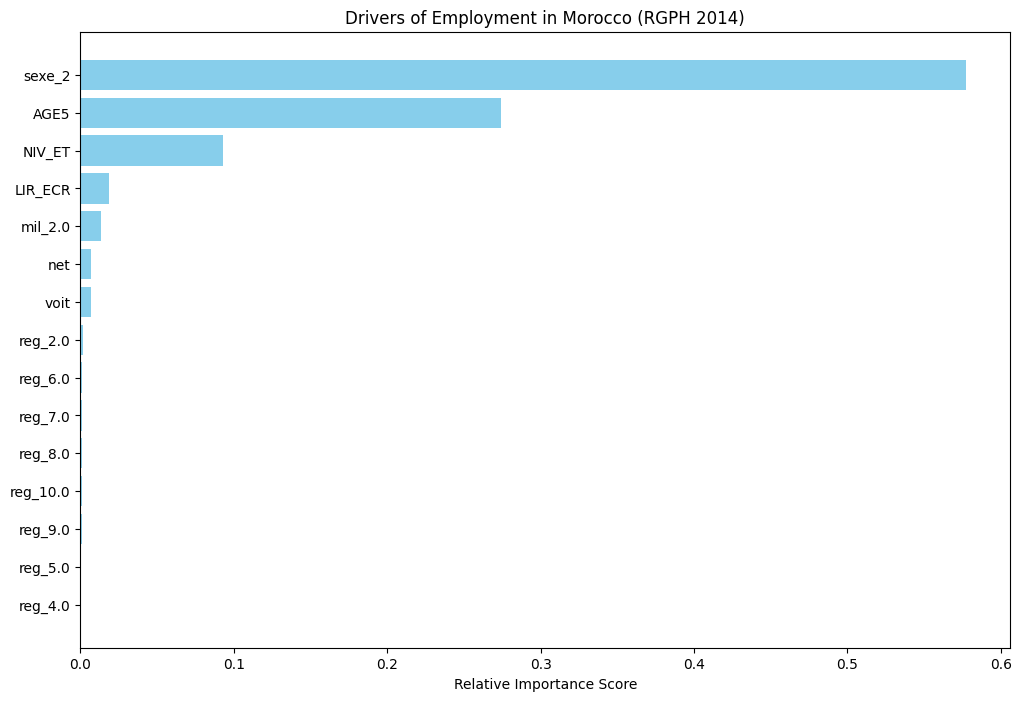

Top 10 Features:
    Feature  Importance
17   sexe_2    0.577347
0      AGE5    0.274059
1    NIV_ET    0.092725
2   LIR_ECR    0.018705
16  mil_2.0    0.013623
3       net    0.006708
4      voit    0.006637
5   reg_2.0    0.001638
9   reg_6.0    0.001325
10  reg_7.0    0.001306


In [ ]:

print("\nStep 5: Generating Importance Report")

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(12, 8))
plt.title('Drivers of Employment in Morocco (RGPH 2014)')
plt.barh(importance_df['Feature'][:15], importance_df['Importance'][:15], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Relative Importance Score')
plt.show()

print("Top 10 Features:")
print(importance_df.head(10))

In [ ]:
print(f"Unique Provinces: {df['pro'].nunique()}")
print(f"Unique Households: {df['MEN_PRO'].nunique()}")

Unique Provinces: 72
Unique Households: 81810


In [ ]:
# Create a test grid
test_grid = []
for edu in sorted(df['NIV_ET'].unique()):
    test_grid.append([30, edu, 0, 0, 1, 0]) # Male, Age 30, Urban, Literate
    test_grid.append([30, edu, 1, 0, 1, 0]) # Female, Age 30, Urban, Literate

# (Note: You'll need to adjust the list to match your exact X.columns order)
# This helps you see if the "Gender Gap" narrows as Education increases.

In [ ]:
def predict_employment(age, education, sexe, milieu, has_net=True, has_car=False):
    """
    sexe: 'femme' ou 'homme'
    milieu: 'urbain' ou 'rural'
    """
    # 1. Préparation de la liste des caractéristiques (toutes à 0 par défaut)
    feature_names = list(X.columns)
    input_vector = [0.0] * len(feature_names)
    
    # 2. Variables Numériques
    input_vector[feature_names.index('AGE5')] = float(age)
    input_vector[feature_names.index('NIV_ET')] = float(education)
    input_vector[feature_names.index('LIR_ECR')] = 1.0 # Sait lire et écrire
    
    # net: 1 pour Oui, 2 pour Non (selon votre encodage précédent)
    if 'net' in feature_names:
        input_vector[feature_names.index('net')] = 1.0 if has_net else 2.0
    if 'voit' in feature_names:
        input_vector[feature_names.index('voit')] = 1.0 if has_car else 0.0
    
    # 3. Variables Catégorielles (Dummies)
    # sexe_2 correspond généralement à 'femme' dans un drop_first=True
    if sexe.lower() == 'femme' and 'sexe_2' in feature_names:
        input_vector[feature_names.index('sexe_2')] = 1.0
        
    # mil_2.0 correspond généralement à 'rural'
    if milieu.lower() == 'rural' and 'mil_2.0' in feature_names:
        input_vector[feature_names.index('mil_2.0')] = 1.0
        
    # 4. Calcul de la probabilité
    # [input_vector] transforme la liste en une ligne de matrice (2D)
    prob = model.predict_proba([input_vector])[0][1]
    
    return prob

# --- EXEMPLES DE TESTS ---
p_homme = predict_employment(30, 16, 'homme', 'urbain')
p_femme = predict_employment(30, 16, 'femme', 'urbain')

print(f"Probabilité d'emploi (Homme, 30 ans, Urbain) : {p_homme:.2%}")
print(f"Probabilité d'emploi (Femme, 30 ans, Urbain) : {p_femme:.2%}")

Probabilité d'emploi (Homme, 30 ans, Urbain) : 80.33%
Probabilité d'emploi (Femme, 30 ans, Urbain) : 19.61%


c:\Users\SAMSUNG\Desktop\DL_test\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\SAMSUNG\Desktop\DL_test\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [5]:
# Charger votre modèle actuel qui est trop lourd
model = joblib.load('../morocco_employment_model.pkl')

# Le sauvegarder à nouveau avec compression (0 à 9, 3 est un bon compromis)
# Cela va réduire la taille du fichier drastiquement (souvent de 100Mo à 30Mo)
joblib.dump(model, 'morocco_employment_model.pkl', compress=3)

print("Modèle compressé avec succès !")

Modèle compressé avec succès !
